# Task 4: Email Spam Detection with Machine Learning

**Internship:** OIBSIP
**Name:** Pragyan Kumar Beheruk
**Task:** Task 4 — Email Spam Detection with Machine Learning (NLP)

**Objective:** Build an NLP binary classifier that distinguishes spam emails/SMS from legitimate (ham) messages.

**Dataset:** SMS Spam Collection Dataset (self-sourced from Kaggle / UCI Machine Learning Repository), containing 5,572 labeled SMS messages.

**Tech Stack:** Python, pandas, scikit-learn (TF-IDF, Naive Bayes, Logistic Regression), NLTK, Matplotlib, Seaborn, WordCloud


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


[nltk_data] Downloading package stopwords to C:\Users\Pragyan
[nltk_data]     Beheruk\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


## 2. Data Loading and Class Distribution

In [2]:
# Load dataset (SMS Spam Collection format: v1 = label, v2 = message text)
df = pd.read_csv('spam.csv', encoding='latin-1')

# Keep only the relevant columns and rename them
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
# Check for missing values and duplicates
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# Drop duplicates
df = df.drop_duplicates().reset_index(drop=True)
print("\nShape after removing duplicates:", df.shape)


Missing values:
 label      0
message    0
dtype: int64

Duplicate rows: 403

Shape after removing duplicates: (5169, 2)


Class counts:
 label
ham     4516
spam     653
Name: count, dtype: int64

Class percentage:
 label
ham     87.37
spam    12.63
Name: proportion, dtype: float64


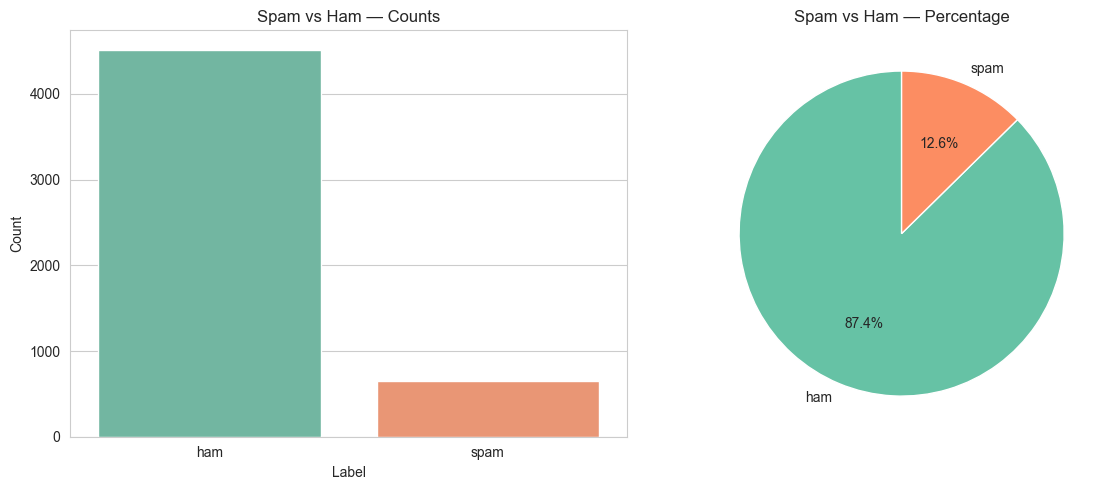

In [4]:
# Class distribution: spam vs ham counts and percentage
class_counts = df['label'].value_counts()
class_pct = df['label'].value_counts(normalize=True) * 100

print("Class counts:\n", class_counts)
print("\nClass percentage:\n", class_pct.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='label', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Spam vs Ham — Counts')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')

axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2'), startangle=90)
axes[1].set_title('Spam vs Ham — Percentage')

plt.tight_layout()
plt.savefig('outputs/01_Class_Distribution.png', dpi=150)
plt.show()


**Observation:** The dataset is imbalanced — ham (legitimate) messages significantly outnumber spam messages. This imbalance is important to keep in mind when evaluating the model, since accuracy alone can be misleading (a model predicting "ham" for everything would still score high accuracy).

## 3. Text Preprocessing Pipeline

The following preprocessing pipeline is applied to every message before feature extraction:

1. **Lowercase conversion** — normalizes text so "Free" and "free" are treated the same.
2. **URL removal** — strips links which don't carry generalizable word-level meaning.
3. **Punctuation removal** — removes symbols like `!`, `$`, `.` that aren't useful as standalone tokens.
4. **Digit removal** — removes standalone numbers (phone numbers, prices) that add noise.
5. **Stopword removal** — removes common words (e.g. "the", "is", "and") that carry little classification signal, using NLTK's English stopword list.
6. **Stemming** — reduces words to their root form (e.g. "winning" → "win") using the Porter Stemmer, so different forms of a word are treated the same by the model.

In [5]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # 3. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 4. Remove digits
    text = re.sub(r'\d+', '', text)
    # 5. Tokenize (simple whitespace split) + remove stopwords + 6. Stem
    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words and len(word) > 1]
    return ' '.join(tokens)

df['clean_message'] = df['message'].apply(preprocess_text)
df[['message', 'clean_message']].head(10)


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi great world l...
1,Ok lar... Joking wif u oni...,ok lar joke wif oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,dun say earli hor alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darl week word back id like fun st...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request mell mell oru minnaminungint nurun...
8,WINNER!! As a valued network customer you have...,winner valu network custom select receivea å£ ...
9,Had your mobile 11 months or more? U R entitle...,mobil month entitl updat latest colour mobil c...


## 4. Feature Extraction — TF-IDF Vectorization

**What TF-IDF measures:** TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numeric features by scoring how important a word is to a specific message relative to the whole dataset.

- **Term Frequency (TF):** how often a word appears in a given message — the more it appears, the higher its local weight.
- **Inverse Document Frequency (IDF):** down-weights words that appear in *many* messages across the dataset (e.g. common words like "call" or "free" in spam), and up-weights words that are rarer and more distinctive.
- **TF-IDF score = TF × IDF:** a word gets a high score only if it appears frequently in one message but is relatively rare across the whole corpus — meaning it's likely a strong, distinguishing signal for classification, rather than just a generically common word.

In [6]:
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['clean_message']).toarray()

# Encode labels: ham = 0, spam = 1
y = df['label'].map({'ham': 0, 'spam': 1})

print("Feature matrix shape:", X.shape)
print("Label distribution:\n", y.value_counts())


Feature matrix shape: (5169, 3000)
Label distribution:
 label
0    4516
1     653
Name: count, dtype: int64


## 5. Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])


Training set size: 4135
Test set size: 1034


## 6. Model Training — Multinomial Naive Bayes + Logistic Regression

In [8]:
# Model 1: Multinomial Naive Bayes (industry standard for text classification)
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

# Model 2: Logistic Regression (alternative classifier)
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("Both models trained successfully.")


Both models trained successfully.


## 7. Evaluation — Accuracy, Precision, Recall, F1-score, Confusion Matrix

In [9]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print()
    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-score': f1}

results = []
results.append(evaluate_model("Multinomial Naive Bayes", y_test, nb_preds))
results.append(evaluate_model("Logistic Regression", y_test, lr_preds))

results_df = pd.DataFrame(results)
results_df


--- Multinomial Naive Bayes ---
Accuracy : 0.9729
Precision: 0.9905
Recall   : 0.7939
F1-score : 0.8814

--- Logistic Regression ---
Accuracy : 0.9565
Precision: 1.0000
Recall   : 0.6565
F1-score : 0.7926



,Model,Accuracy,Precision,Recall,F1-score
0,Multinomial Naive Bayes,0.972921,0.990476,0.793893,0.881356
1,Logistic Regression,0.956480,1.000000,0.656489,0.792627


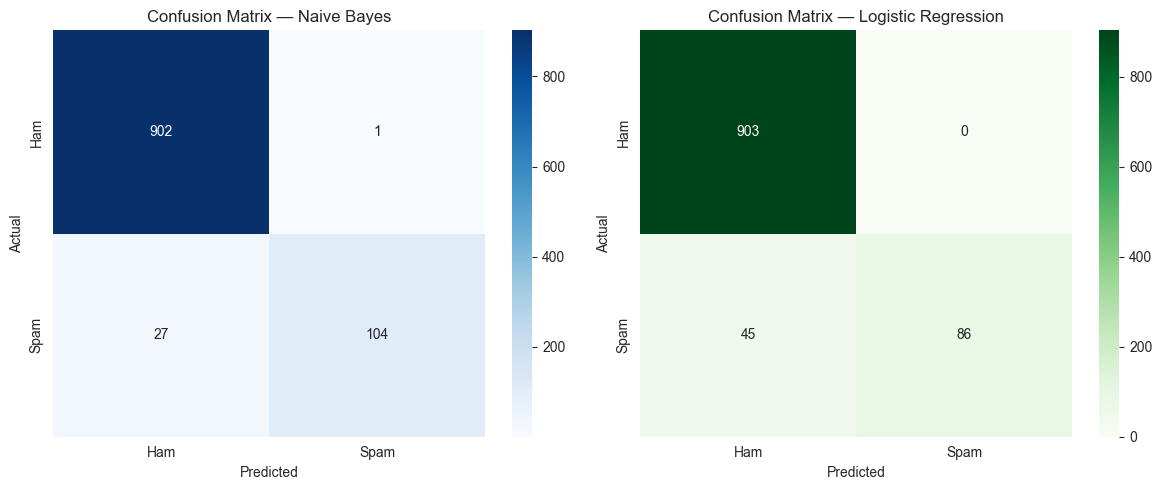

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_nb = confusion_matrix(y_test, nb_preds)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'], ax=axes[0])
axes[0].set_title('Confusion Matrix — Naive Bayes')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_lr = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'], ax=axes[1])
axes[1].set_title('Confusion Matrix — Logistic Regression')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('outputs/02_Confusion_Matrices.png', dpi=150)
plt.show()


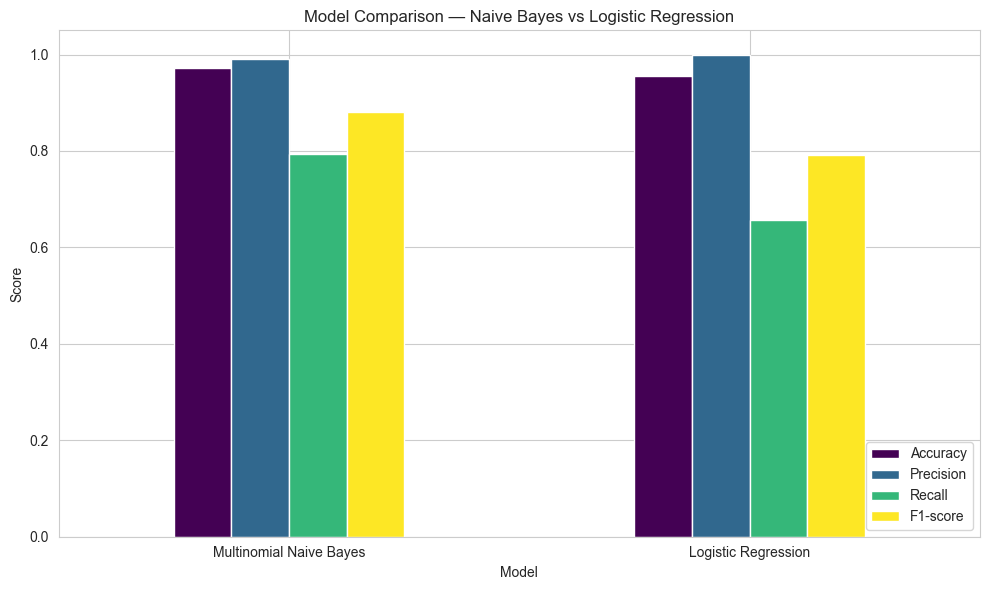

In [11]:
# Model comparison bar chart
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-score']].plot(
    kind='bar', figsize=(10, 6), colormap='viridis'
)
plt.title('Model Comparison — Naive Bayes vs Logistic Regression')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('outputs/03_Model_Comparison.png', dpi=150)
plt.show()


## 8. Discussion — Why is Recall Important for Spam Detection?

In spam detection, **recall** measures how many of the *actual* spam messages the model successfully catches (True Positives / (True Positives + False Negatives)).

Recall matters more than it might in other problems because of the **asymmetric cost of errors**:

- A **False Negative** (a real spam message misclassified as ham) means spam reaches the user's inbox — annoying, but also potentially exposing them to phishing, scams, or malware.
- A **False Positive** (a real ham message misclassified as spam) means a legitimate email gets filtered out — which can also be costly (e.g. missing an important message), but is usually easier to notice and recover from by checking the spam folder.

Because missed spam (low recall) can have serious consequences — financial fraud, phishing, security risks — a good spam filter should prioritize **high recall for the spam class**, catching as much spam as possible, while still keeping precision reasonably high so it doesn't bury real messages in the spam folder. In practice, the ideal system balances both (via the F1-score), but recall is the metric most directly tied to *not letting harmful content slip through*.

## 9. Bonus — WordCloud Visualizations for Spam and Ham Words

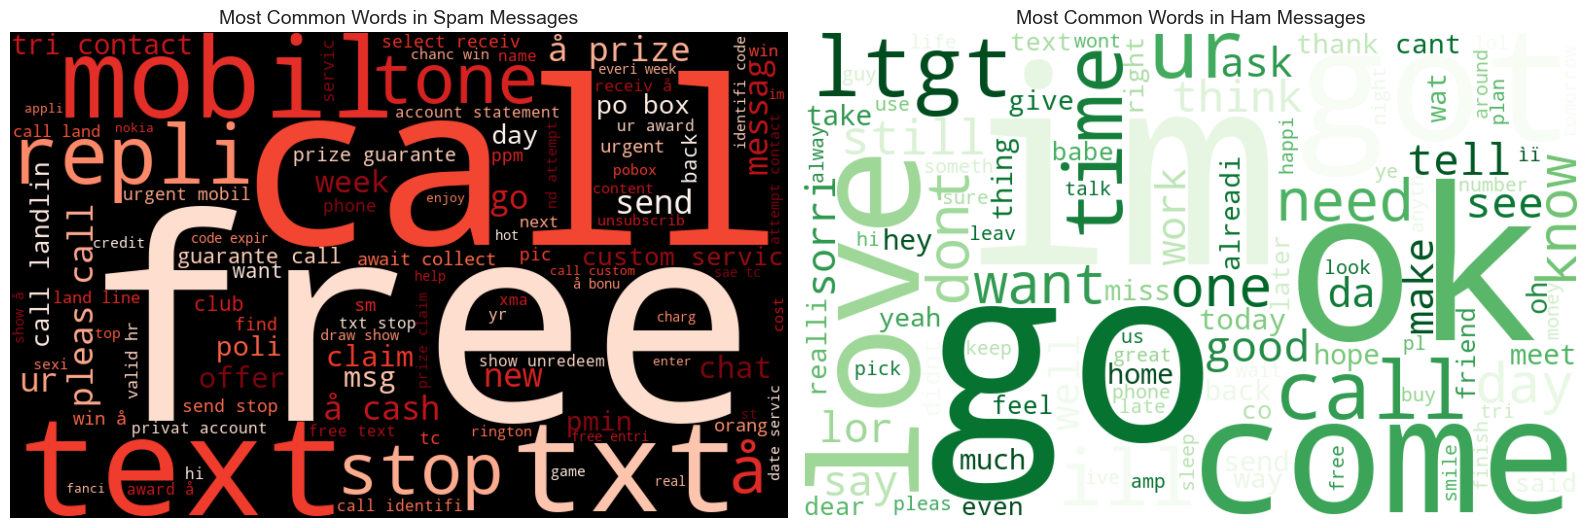

In [12]:
spam_text = ' '.join(df[df['label'] == 'spam']['clean_message'])
ham_text = ' '.join(df[df['label'] == 'ham']['clean_message'])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

spam_wc = WordCloud(width=800, height=500, background_color='black',
                     colormap='Reds', max_words=100).generate(spam_text)
axes[0].imshow(spam_wc, interpolation='bilinear')
axes[0].set_title('Most Common Words in Spam Messages', fontsize=14)
axes[0].axis('off')

ham_wc = WordCloud(width=800, height=500, background_color='white',
                    colormap='Greens', max_words=100).generate(ham_text)
axes[1].imshow(ham_wc, interpolation='bilinear')
axes[1].set_title('Most Common Words in Ham Messages', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('outputs/04_WordClouds.png', dpi=150)
plt.show()


## 10. Conclusion

- Both **Multinomial Naive Bayes** and **Logistic Regression** were trained on TF-IDF features extracted from cleaned SMS text.
- Model performance was compared using accuracy, precision, recall, and F1-score, with confusion matrices to visualize error types.
- Recall was highlighted as a particularly important metric for spam detection, since missed spam (false negatives) carries higher real-world risk than an occasional false positive.
- WordCloud visualizations confirmed intuitive patterns — spam messages are dominated by promotional/urgency words (e.g. "free", "win", "call", "urgent"), while ham messages reflect everyday conversational language.

**Author:** Pragyan Kumar Beheruk
**Submission:** OIBSIP — Task 4 — Email Spam Detection with Machine Learning
